In [3]:
import numpy as np
import matplotlib.pyplot as plt

from edibles.utils.local_continuum_spline import *

from edibles.utils.final_voigt_profile import *
from edibles.utils.final_fitter import *

from edibles.utils.edibles_oracle import EdiblesOracle
from edibles.utils.edibles_spectrum import EdiblesSpectrum 
## in the earlier codes these 2 lines were not needed as this ipynb file used to sit inside the edibles/utils/ folder.


from IPython.display import display, Math

from scipy.interpolate import CubicSpline


from edibles.utils3 import *

In [ ]:
sightline = "HD 170740"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=4232.0)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=4232.0)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)


/Users/ayansahoo/Desktop/MITACS_2024_Canada/edibles/DR4
***Common Objects***
['HD 170740']
**Filtered File List**
6354    /HD170740/BLUE_437/HD170740_w437_blue_20170705...
6362    /HD170740/BLUE_437/HD170740_w437_n14_20170705_...
6381    /HD170740/BLUE_437/HD170740_w437_blue_20160613...
6391    /HD170740/BLUE_437/HD170740_w437_blue_20160613...
6397    /HD170740/BLUE_437/HD170740_w437_n20_20140915_...
6398    /HD170740/BLUE_437/HD170740_w437_n20_20140916_...
6419    /HD170740/BLUE_437/HD170740_w437_blue_20140916...
6424    /HD170740/BLUE_437/HD170740_w437_blue_20140915...
6425    /HD170740/BLUE_437/HD170740_w437_n20_20150626_...
6428    /HD170740/BLUE_437/HD170740_w437_blue_20140915...
6434    /HD170740/BLUE_437/HD170740_w437_blue_20150626...
6435    /HD170740/BLUE_437/HD170740_w437_n10_20160613_...
6441    /HD170740/BLUE_437/HD170740_w437_blue_20150626...
6446    /HD170740/BLUE_437/HD170740_w437_blue_20140916...
6478    /HD170740/BLUE_437/HD170740_w437_blue_20170705...
Name: Filename, 

In [ ]:
for i in test:
    if i.endswith("O15.fits"):
        print(i)

/HD170740/BLUE_437/HD170740_w437_blue_20140915_O15.fits
/HD170740/BLUE_437/HD170740_w437_blue_20160613_O15.fits
/HD170740/BLUE_437/HD170740_w437_blue_20170705_O15.fits
/HD170740/BLUE_437/HD170740_w437_blue_20140916_O15.fits
/HD170740/BLUE_437/HD170740_w437_blue_20150626_O15.fits


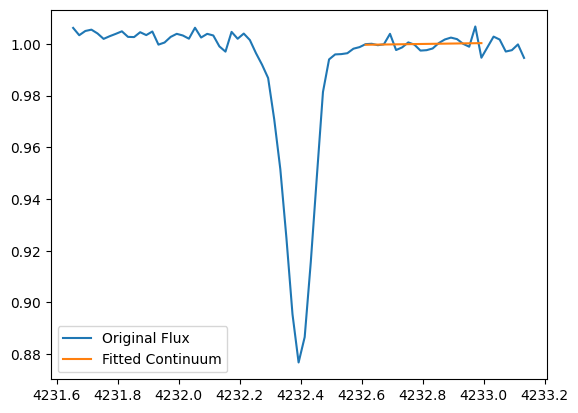

Standard deviation of flux: 0.0025082471483615643


In [10]:
filename = "/HD170740/BLUE_437/HD170740_w437_blue_20140915_O15.fits" # mention the file which needs fitting
wrange = [4231.65, 4233.15]
sp = EdiblesSpectrum(filename)
sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
wave = sp.bary_wave
flux = sp.bary_flux

# Filter the spectrum within the specified wavelength range
idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
wave = wave[idx]
flux = flux[idx]
# Normalize the flux
flux = flux / np.median(flux)
continuum, std_dev = local_continuum(wave, flux, positions=[4232.8], windows=[0.4], spline_order=1, silent=False)

## this local_continuum function is different from what is in the edibles repo. it was created by us and is in a email sent by Debayan 

print("Standard deviation of flux:", std_dev)

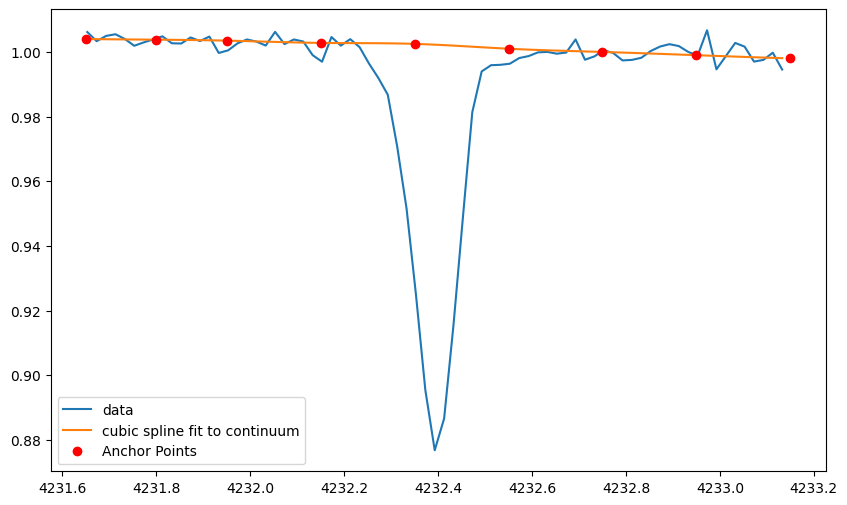

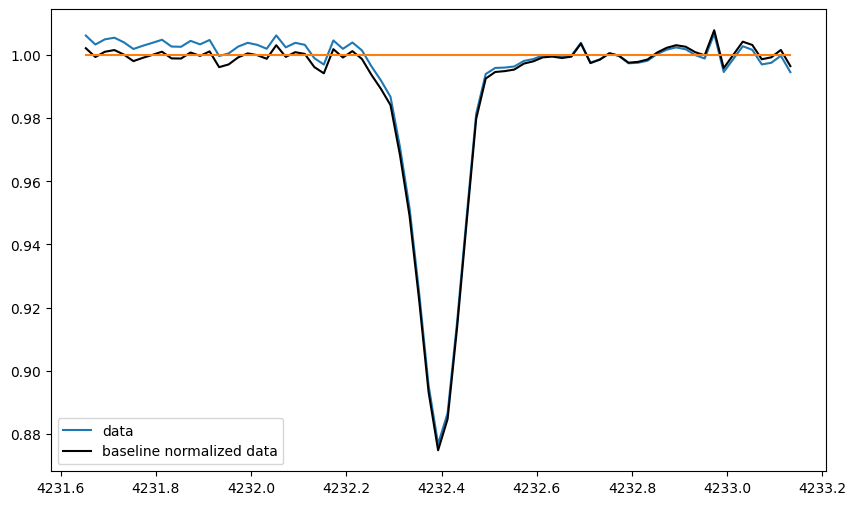

In [11]:
## next try to fit continuum using cubic splines

anchor_points_wave = np.array([4231.65, 4231.8, 4231.95, 4232.15, 4232.35, 4232.55, 4232.75, 4232.95, 4233.15])
anchor_points_flux = np.array([1.004, 1.0038, 1.0035, 1.0028, 1.0025, 1.001, 1.00, 0.999, 0.998])

# anchor_points_wave = np.array([4231, 4231.25, 4231.5, 4231.75, 4232, 4232.12, 4232.29, 4232.72, 4232.85, 4233])
# anchor_points_flux = np.interp(anchor_points_wave, wave, flux)

# Fit cubic splines to the anchor points
cs = CubicSpline(anchor_points_wave, anchor_points_flux) # so the cubic spline routine is not really taking all the points into account. only anchors

# Generate the continuum model
continuum = cs(wave)

plt.figure(figsize=(10, 6))
plt.plot(wave, flux, label='data')
plt.plot(wave, continuum, label='cubic spline fit to continuum')
plt.plot(anchor_points_wave, anchor_points_flux, 'ro', label='Anchor Points')
plt.legend()
plt.show()

H = np.ones(wave.shape)
plt.figure(figsize=(10, 6))
plt.plot(wave, flux, label='data')
plt.plot(wave, flux / continuum, color='k', label='baseline normalized data')
plt.plot(wave, H)
plt.legend()
plt.show()

In [14]:
# Known params
lambda0 = [4232.548, 4232.548]
wavegrid = wave
f = [0.005450, 0.005450]
gamma = [1e8, 1e8]


# Best-fit params
b = [3.05, 5.27]  # in km/s
v_rad = [-10.3, -12.2] # in km/s
N = [10**(12.9513), 10**(12.9301)]  # in cm^-2


model_fit = model.mother_function(wavegrid, lambda0=0.0, f=0.0, gamma=0.0, b=0.0, 
                    N=0.0, v_rad=0.0, v_resolution=3.0)


plt.figure(figsize=(10, 6))
plt.plot(wave, flux, label='data')
plt.plot(wave, continuum * model_fit, label='Best-fit model')
plt.plot(wave, continuum, label='continuum')
plt.legend()
plt.show()


NameError: name 'model' is not defined